In [1]:
import os
# Set the environment variable to disable hash randomization
os.environ['PYTHONHASHSEED'] = '0'
#If you find discrepancies between the UMAP and Leiden results, indicating reproducibility issues, 
#please refer to this link: https://github.com/scverse/scanpy/issues/1009 for potential solutions.
#https://umap-learn.readthedocs.io/en/latest/reproducibility.html
# set export OMP_NUM_THREADS=1 Multithreading can lead to reproducibility issues!!!
#Theoretically, minor differences in UMAP and inconsistencies in Leiden clustering do not affect their biological significance.
import scanpy as  sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import seaborn as sns
import scanpy.external as sce
import loompy
import harmonypy as hm
print('import successful')
#import scanpy as sc, scvi, torch
from pathlib import Path
from typing import List
import matplotlib


import successful


In [2]:
def update_cell_annotations(adata, clustering_column, new_cell_type_dict, update_cell_type):
    if not update_cell_type:
        print("细胞注释更新被禁用")
        return adata


    cluster_to_celltype = {}

    for cell_type, clusters in new_cell_type_dict.items():
        for cluster in clusters:
            cluster_to_celltype[str(cluster)] = cell_type
    adata.obs['celltype'] = adata.obs[clustering_column].map(cluster_to_celltype)

    print("finish updata_cell_annotation")
    print(adata.obs['celltype'].value_counts())
    #print(adata.obs['celltype'].value_counts())
    return adata

In [3]:
def run_harmony(adata,vars_use):
    print('running harmony')
    pca_result = adata.obsm['X_pca']
    ho = hm.run_harmony(pca_result, adata.obs, vars_use,random_state=42)
    adata.obsm['X_pca_harmony'] = ho.Z_corr.T
    print('finished harmony')
    return adata

In [4]:
def run_preprocess(adata,top_genes):
    adata.X=adata.layers["counts"].copy()
    # Normalizing to median total counts
    sc.pp.normalize_total(adata)
    # Logarithmize the data
    sc.pp.log1p(adata)
    adata.raw=adata
    adata.layers["normalized"] = adata.X.copy()
    print('Finish normalized')
    sc.pp.highly_variable_genes(adata, n_top_genes=top_genes)
    sc.pl.highly_variable_genes(adata)
    print('Finish Varible genes')

In [5]:
def run_reduceDimension(ea,use_scvi,runharmony,PCs,res,vars_use):
    import scanpy as  sc
    sc.pp.scale(ea,max_value=10)
    sc.tl.pca(ea,mask_var="highly_variable")
    sc.pl.pca_variance_ratio(ea,log = False)
    if use_scvi:   
        import os
        import tempfile
        import scanpy as sc
        import scvi
        import seaborn as sns
        import torch
        from scib_metrics.benchmark import Benchmarker
        scvi.settings.seed = 0
        print("Last run with scvi-tools version:", scvi.__version__)
        ea=run_scvi(ea)
        sc.pl.embedding(
            ea,
            basis=SCVI_MDE_KEY,
            color=['stage', "leiden",'celltype'],
            frameon=False,
            ncols=1,
            save=f'{dataset}_SCVI.png',
        )
    else:
        print('skip scvi')
    if runharmony:
        run_harmony(ea,vars_use)
        sc.pp.neighbors(ea, use_rep='X_pca_harmony',n_pcs=PCs,random_state=42,n_neighbors=15)
        print('Finish neighbors')
    else:
        sc.pp.neighbors(ea,n_pcs=PCs,random_state=42)
        print('Finish neighbors')
    sc.tl.leiden(ea,resolution = res,random_state=42)
    print('Finish clustering')
    sc.tl.umap(ea,random_state=42)
    print('Finish UMAP')

In [6]:
def do_umap_plots(ea,dataset,Featuregenes,doFeatureplot):
    sc.settings.figdir = ''
    sc.pl.umap(
        ea,
        color=["celltype",'leiden'],
        # increase horizontal space between panels
        wspace=0.5,
        size=3,
    ncols=3,
    save=f'{dataset}_cluster.png',
    color_map='viridis'
    )

    if doFeatureplot:
        sc.pl.umap(
            ea,
            color=[*Featuregenes,'celltype'],
            # increase horizontal space between panels
            wspace=0.5,
            size=3,
        ncols=4,
        save=f'{dataset}_cluster_feature.png',gene_symbols='gene_name',
        color_map='plasma'
        )
        print('Featureplot Finished')
    else:
        print('666666')


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def do_cell_barplot(ea, dataset, celltypename):
    # 确保用于分组的列是 category 类型
    if not pd.api.types.is_categorical_dtype(ea.obs[celltypename]):
        print(f"Warning: Column '{celltypename}' is not categorical. Converting...")
        ea.obs[celltypename] = ea.obs[celltypename].astype('category')
        
    # --- 1. 计算细胞类型比例 ---
    celltype_counts = ea.obs.groupby(['stage', celltypename]).size().unstack(fill_value=0)
    celltype_percentages = celltype_counts.div(celltype_counts.sum(axis=1), axis=0) * 100

    # --- 2. (修正) 创建一个从“细胞类型名称”到“颜色”的映射字典 ---
    # 这可以防止字母顺序和类别顺序不一致导致的错误
    try:
        categories = ea.obs[celltypename].cat.categories
        color_list = ea.uns[f'{celltypename}_colors']
        if len(categories) != len(color_list):
            raise ValueError(f"Color list ({len(color_list)}) and category ({len(categories)}) lengths differ.")
            
        color_map = dict(zip(categories, color_list))
    except Exception as e:
        print(f"Error creating color map: {e}. Plotting may fail or use default colors.")
        # 如果出错，提供一个回退方案（但这很可能不匹配）
        color_map = {ct: color for ct, color in zip(celltype_counts.columns, ea.uns[f'{celltypename}_colors'])}


    # --- 3. 准备绘图数据 ---
    # 对 stage 按降序排列
    celltype_percentages = celltype_percentages.sort_index(ascending=False)
    times = celltype_percentages.index  # 排序后的 stage 顺序
    
    # (修正) 按类别顺序获取要绘制的细胞类型
    # 这样可以保证堆叠顺序和图例顺序与 AnnData 一致
    cell_types_to_plot = [ct for ct in categories if ct in celltype_percentages.columns]
    
    bottom = pd.Series([0] * len(times), index=times)

    # --- 4. 绘图 ---
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_width = 0.8  

    # (修正) 使用排序后的列表和颜色映射
    for cell_type in cell_types_to_plot:
        percentages = celltype_percentages[cell_type]
        # 从字典中安全地获取颜色
        color = color_map.get(cell_type, '#808080') # 如果找不到颜色，用灰色
        
        ax.barh(times, percentages, left=bottom, color=color, label=cell_type, height=bar_width)
        bottom += percentages

    # --- 5. 设置格式和保存 ---
    ax.set_title(f'Percentage of Each Celltype Over Stage in {dataset}', fontsize=16)
    ax.set_xlabel('Percentage', fontsize=14)
    ax.set_ylabel('Stage', fontsize=14)

    ax.legend(title='Celltype', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.savefig(f"{dataset}_{celltypename}_bar_plot.png", dpi=300)
    plt.savefig(f"{dataset}_{celltypename}_bar_plot.pdf")
    plt.show()

In [8]:
def rasterize_scanpy_scatter(fig: matplotlib.figure.Figure):
    """Rasterize PathCollection(s) in a Scanpy plot, keeping text/legend vector."""
    for ax in fig.axes:
        for col in ax.collections:
            try:
                col.set_rasterized(True)
            except Exception:
                pass


def plot_umap_gridpdf_scanpy(adata, group_col: str, out_pdf: Path, title: str,DPI):
    sc.pl.umap(
        adata,
        color=group_col,
        title=title,
        show=False,ncols=1
    )
    fig = plt.gcf()
    rasterize_scanpy_scatter(fig)
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

In [27]:
PCs = 20
res = 0.3
top_genes=2000
dataset = 'S-MG'
h5adpath = f''
celltypelist = ['Luminal epithelial cells','Basal epithelial cells','Proliferating epithelial cells','Keratinized epithelial cells']
vars_use=['sample']
update_cell_type = False
Featuregenes = ['Esr1','Epcam','Lalba','Top2a','Pgr','Prlr','Acta2','Elf5','Tcf4','Krt1','Ar','Pigr','Cd69','Adipoq','Lum','Vim','Ptprc','Lef1','Tpm2','Krt23','Krt10','Faah','Tm4sf1','Ppl','Wnt11','Krtdap','Sbsn','Dsp','Rab25','Aqp3','Shh','Atp1a1','Atp1b1','Procr','Col1a1','Krt8','Krt18','Krt14','Krt7','Krt5','Csn1s1','Csn2','Csn3','Xdh']
random.seed(2024)
np.random.seed(2024)
#cells = 5000
doFeatureplot = True
runharmony = True
#subset_celltype = True
#do_subset_cluster = False
#random_subset_cells = False
use_scvi=False

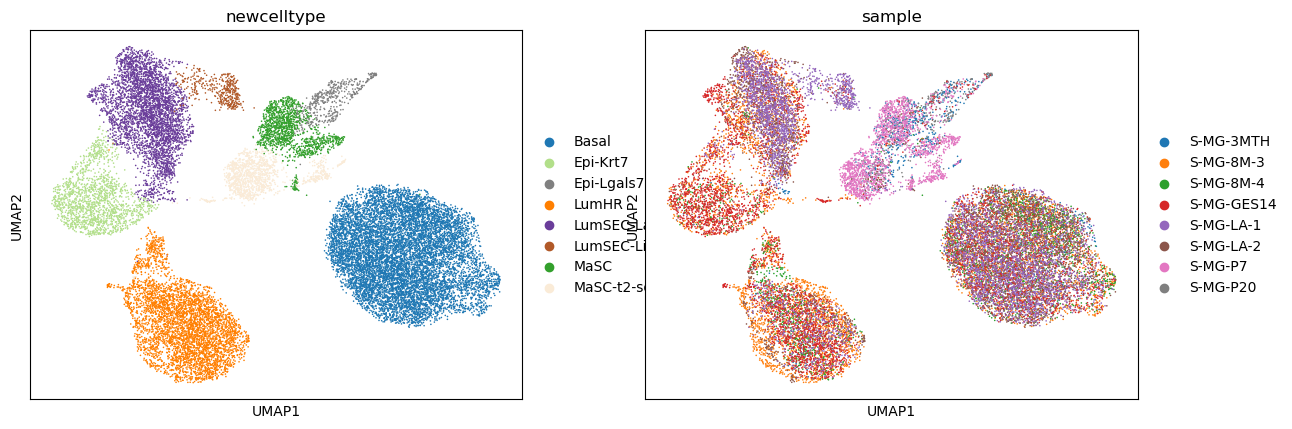

In [28]:
ea = sc.read_h5ad(f'D:/111/{dataset}_cleaned.h5ad')
ea
sc.pl.umap(ea,color=['newcelltype','sample'])

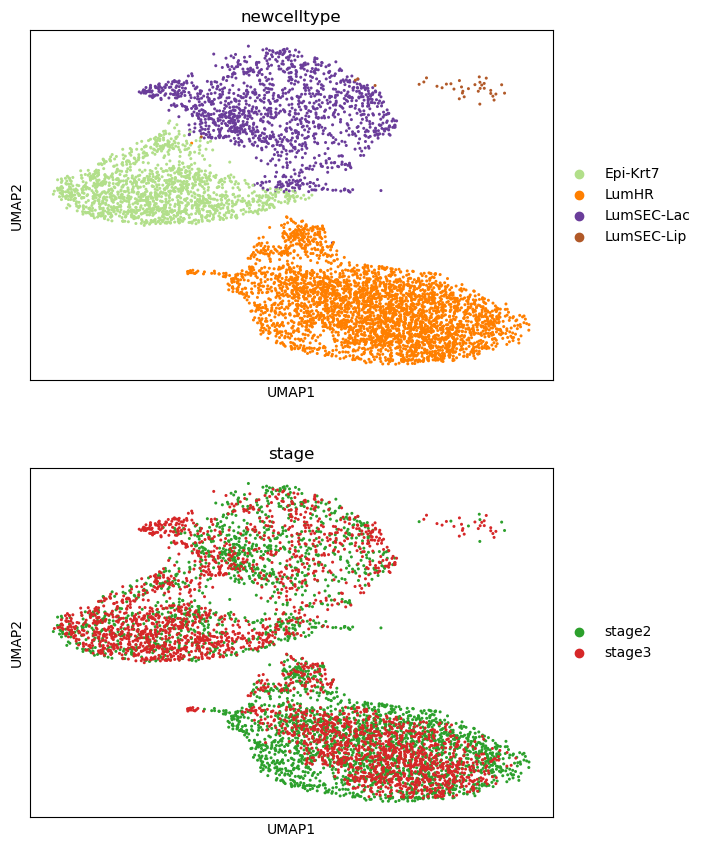

In [29]:
#ea= ea[ea.obs['sample'].isin(['S-MG-3MTH','S-MG-8M-4','S-MG-8M-3']),:]
ea= ea[ea.obs['stage'].isin(['stage2','stage3']),:]
ea = ea[~ea.obs['newcelltype'].isin(['MaSC','Basal','MaSC-t2-sg','Epi-Lgals7']), :]

sc.pl.umap(ea,color=['newcelltype','stage'],ncols=1)

In [ ]:
run_preprocess(ea,top_genes=top_genes)

C:\Users\Lenovo\miniconda3\envs\py310\lib\site-packages\anndata\_core\anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)


In [ ]:
run_reduceDimension(ea,use_scvi=use_scvi,runharmony=runharmony,PCs=PCs,res=res,vars_use=vars_use)

In [ ]:
sc.pl.umap(ea,color=['newcelltype','stage','sample'],ncols=1)

In [15]:
NEWCELLTYPE_COL=['newcelltype','sample']
out_pdf =f"{dataset}_umap_HR-KRT7.pdf"
plot_umap_gridpdf_scanpy(ea, NEWCELLTYPE_COL, out_pdf, title=dataset,DPI=300)


In [16]:
ea

AnnData object with n_obs × n_vars = 6323 × 12088
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'gland', 'stage_old', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'total_counts_RIBO', 'pct_counts_RIBO', 'log1p_total_counts_RIBO', 'leiden', 'anno', 'stage_new', 'species', 'celltype', 'stage', 'cellid', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'newcelltype', 'subtype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dendrogram_leiden', 'gland_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'newcelltype_colors', 'pca', 'rank_genes_groups', 'sample_colors', 'stage_colors', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'counts', 'matrix', 'normalized', 'spliced', 'unspliced'
 

In [17]:
ea.X = ea.layers['counts'].copy()

ea.write(f'D:/111/{dataset}_sub_cleaned.h5ad')

In [18]:
PCs = 20
res = 0.3
top_genes=2000
dataset = 'M-MG'
h5adpath = f''
celltypelist = ['Luminal epithelial cells','Basal epithelial cells','Proliferating epithelial cells','Keratinized epithelial cells']
vars_use=['sample']
update_cell_type = True
Featuregenes = ['Esr1','Epcam','Lalba','Top2a','Pgr','Prlr','Acta2','Elf5','Tcf4','Krt1','Ar','Pigr','Cd69','Adipoq','Lum','Vim','Ptprc','Lef1','Tpm2','Krt23','Krt10','Faah','Tm4sf1','Ppl','Wnt11','Krtdap','Sbsn','Dsp','Rab25','Aqp3','Shh','Atp1a1','Atp1b1','Procr','Col1a1','Krt8','Krt18','Krt14','Krt7','Krt5','Csn1s1','Csn2','Csn3','Xdh']
random.seed(2024)
np.random.seed(2024)
#cells = 5000
doFeatureplot = True
runharmony = True
#subset_celltype = True
#do_subset_cluster = False
#random_subset_cells = False
use_scvi=False

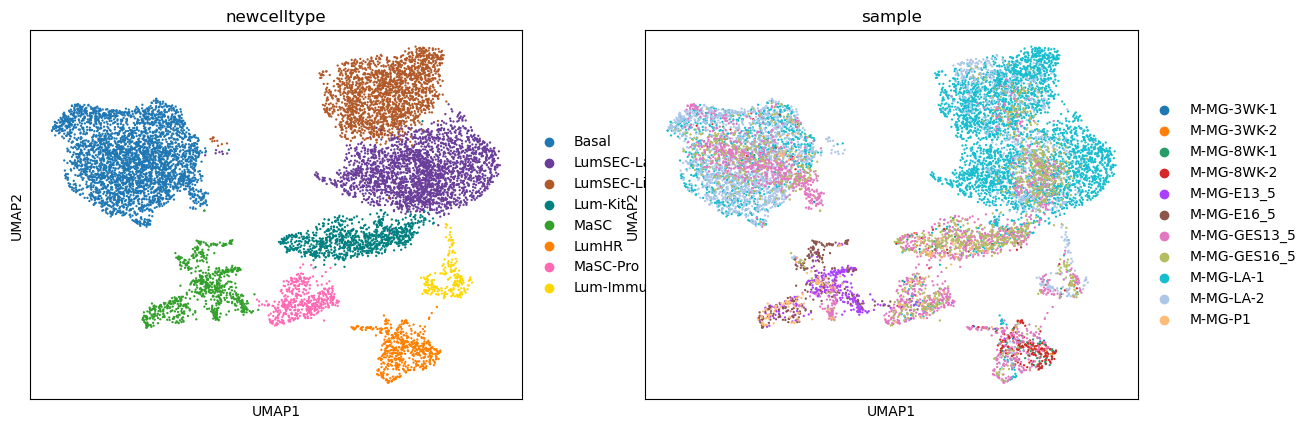

In [19]:
ea = sc.read_h5ad(f'D:/111/{dataset}_cleaned.h5ad')
ea
sc.pl.umap(ea,color=['newcelltype','sample'])

In [20]:
ea

AnnData object with n_obs × n_vars = 10880 × 12088
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'gland', 'stage_old', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'total_counts_RIBO', 'pct_counts_RIBO', 'log1p_total_counts_RIBO', 'leiden', 'anno', 'stage_new', 'species', 'celltype', 'stage', 'cellid', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'newcelltype', 'subtype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dendrogram_leiden', 'gland_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'newcelltype_colors', 'pca', 'rank_genes_groups', 'sample_colors', 'stage_colors', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'counts', 'matrix', 'normalized', 'spliced', 'unspliced'


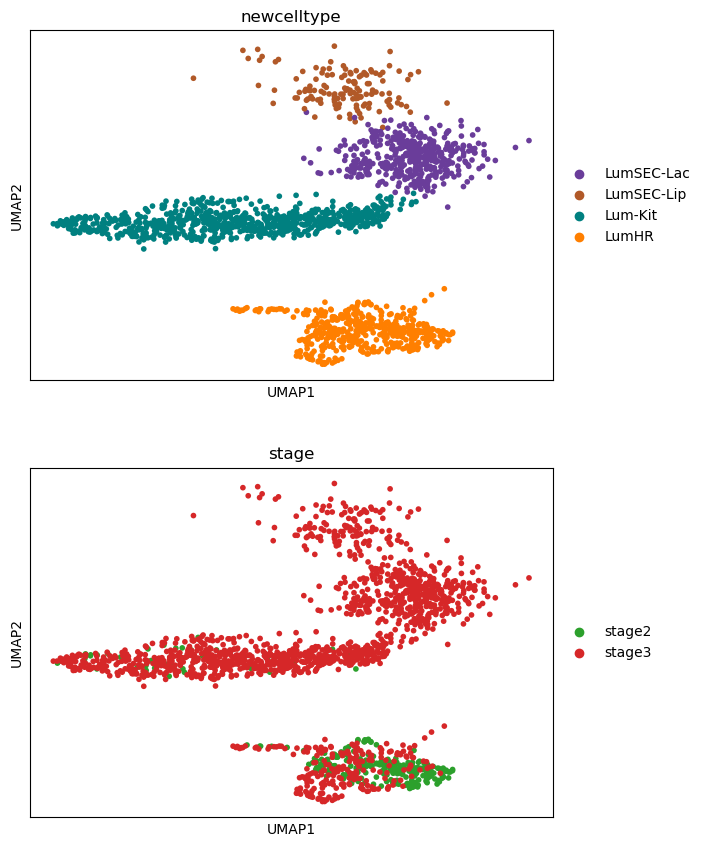

In [21]:
#ea= ea[ea.obs['sample'].isin(['M-MG-3WK-1','M-MG-3WK-2','M-MG-8WK-1','M-MG-8WK-2']),:]
ea= ea[ea.obs['stage'].isin(['stage2','stage3']),:]
ea = ea[ea.obs['newcelltype'].isin(['Lum-Kit','LumHR','LumSEC-Lac','LumSEC-Lip']), :]
sc.pl.umap(ea,color=['newcelltype','stage'],ncols=1)

C:\Users\Lenovo\miniconda3\envs\py310\lib\site-packages\anndata\_core\anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)


C:\Users\Lenovo\miniconda3\envs\py310\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Finish normalized


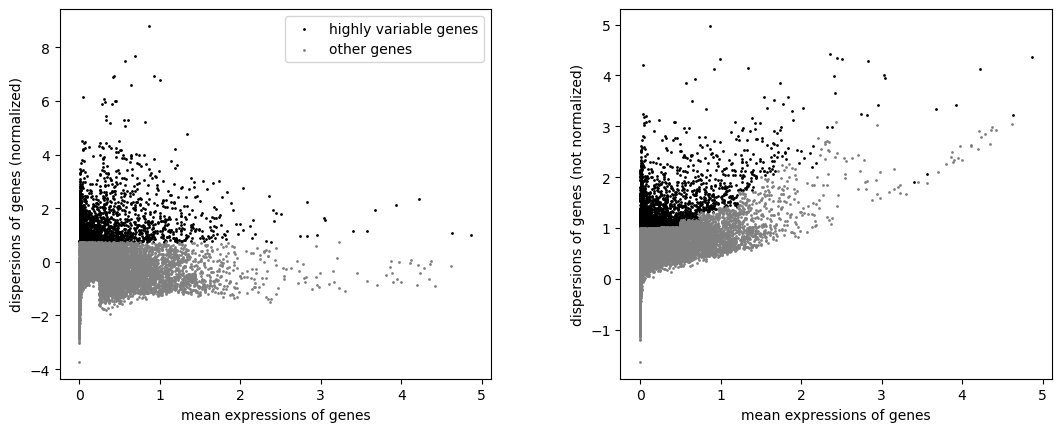

Finish Varible genes


In [22]:
run_preprocess(ea,top_genes=top_genes)

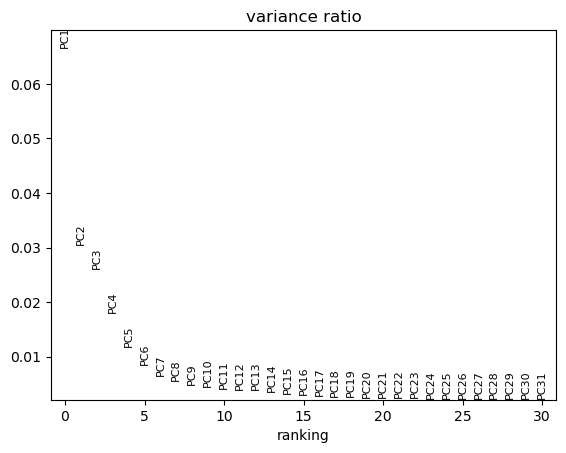

2026-01-23 14:41:41,286 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


skip scvi
running harmony


2026-01-23 14:41:41,641 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-01-23 14:41:41,647 - harmonypy - INFO - Iteration 1 of 10
2026-01-23 14:41:41,790 - harmonypy - INFO - Iteration 2 of 10
2026-01-23 14:41:41,922 - harmonypy - INFO - Converged after 2 iterations


finished harmony
Finish neighbors
Finish clustering
Finish UMAP


In [23]:
run_reduceDimension(ea,use_scvi=use_scvi,runharmony=runharmony,PCs=PCs,res=res,vars_use=vars_use)

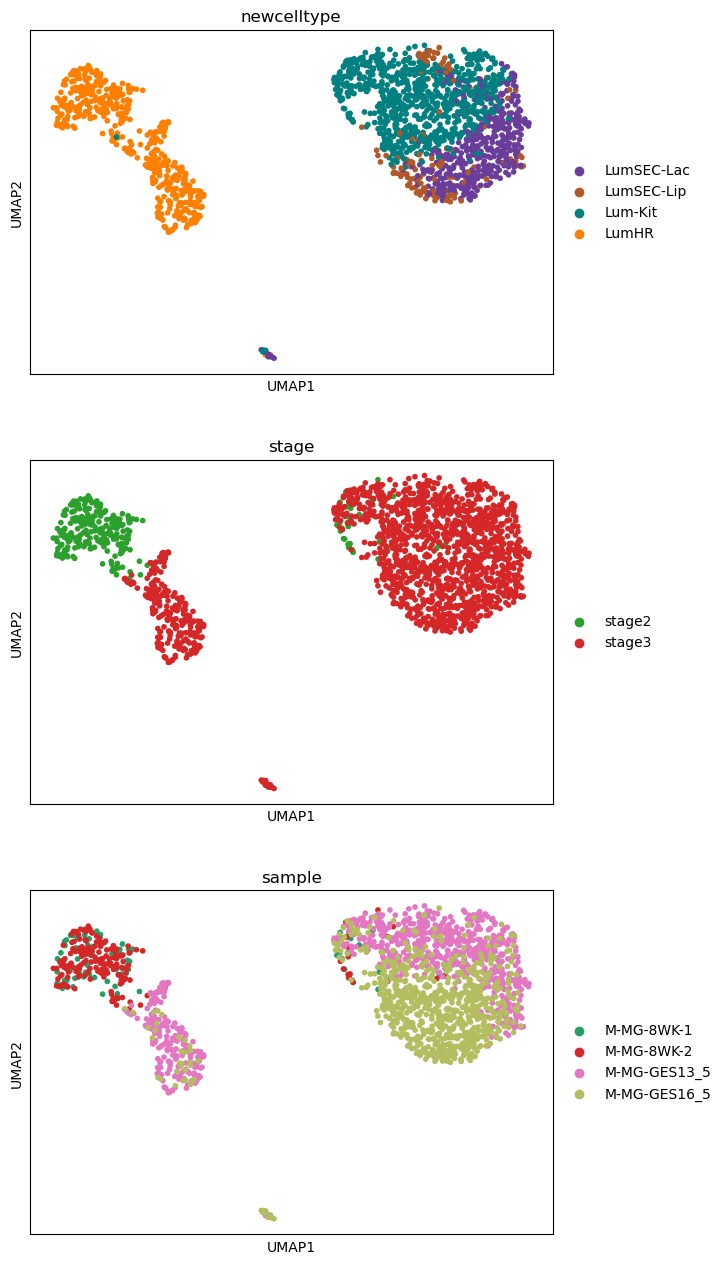

In [24]:
sc.pl.umap(ea,color=['newcelltype','stage','sample'],ncols=1)

In [25]:
NEWCELLTYPE_COL=['newcelltype','sample','stage']
out_pdf =f"{dataset}_umap_HR-KRT7.pdf"
plot_umap_gridpdf_scanpy(ea, NEWCELLTYPE_COL, out_pdf, title=dataset,DPI=300)

In [26]:
ea.X = ea.layers['counts'].copy()
ea.write(f'D:/111/{dataset}_sub_cleaned.h5ad')